In [3]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
# from dynamic_routing_analysis import decoding_utils
# from dynamic_routing_analysis import plot_utils
# from dynamic_routing_analysis import spike_utils

import os
import pingouin as pg

import matplotlib
import matplotlib.font_manager as fm

matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
fm.FontProperties().set_family('arial')

%load_ext autoreload
%autoreload 2
# %matplotlib inline
%matplotlib widget

In [20]:
results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/baseline_context_500ms_leave_2_blocks_out_crossval_10_units_strict_drift_20260609_231148/" #single session


In [21]:
results = pl.scan_parquet(results_path).collect().to_pandas()

In [22]:
results

,balanced_accuracy_test,balanced_accuracy_train,time_aligned_to,bin_size,sliding_window_size,bin_center,shift_idx,repeat_idx,labels,train_test_split_label,...,predict_proba_all_trials,trial_indices,unit_ids,coefs,is_all_trials,session_id,structure,electrode_group_names,unit_subsample_size,unit_criteria
0,0.491248,0.572182,stim_start_time,0.5,None,-0.25,NaN,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",None,...,"[0.4939825893076346, 0.4833284859269377, 0.401...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[670180_2023-07-27_D-102, 670180_2023-07-27_D-...","[-0.054091572966767955, 0.19995718784936123, 0...",True,670180_2023-07-27,ORBvl,[probeD],10,strict_drift
1,0.519378,0.621536,stim_start_time,0.5,None,-0.25,NaN,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",None,...,"[0.2750842405601767, 0.5582559443727455, 0.469...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[670180_2023-07-27_D-17, 670180_2023-07-27_D-2...","[-0.46690198814211126, 0.4926081517130451, 0.0...",True,670180_2023-07-27,ORBvl,[probeD],10,strict_drift
2,0.517737,0.606512,stim_start_time,0.5,None,-0.25,NaN,2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",None,...,"[0.6257806437938108, 0.46252715638420255, 0.52...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[670180_2023-07-27_D-111, 670180_2023-07-27_D-...","[-0.10847602662653215, 0.06355569590196272, -0...",True,670180_2023-07-27,ORBvl,[probeD],10,strict_drift
3,0.494424,0.584579,stim_start_time,0.5,None,-0.25,NaN,3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",None,...,"[0.33605534931661, 0.4384303190569111, 0.53219...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[670180_2023-07-27_D-120, 670180_2023-07-27_D-...","[0.11973869834496137, -0.006075769085589797, -...",True,670180_2023-07-27,ORBvl,[probeD],10,strict_drift
4,0.539416,0.593850,stim_start_time,0.5,None,-0.25,NaN,4,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",None,...,"[0.5665891838677127, 0.4937069274121304, 0.396...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[670180_2023-07-27_D-100, 670180_2023-07-27_D-...","[0.14786118775300108, 0.49887723121702554, 0.0...",True,670180_2023-07-27,ORBvl,[probeD],10,strict_drift
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
570,0.477888,0.558561,stim_start_time,0.5,None,-0.25,NaN,20,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",None,...,"[0.5862426707367262, 0.4536641408396724, 0.501...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[670180_2023-07-27_C-190, 670180_2023-07-27_C-...","[-0.2677688374710679, 0.03454783037916014, 0.5...",True,670180_2023-07-27,CA1,[probeC],10,strict_drift
571,0.477250,0.573729,stim_start_time,0.5,None,-0.25,NaN,21,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",None,...,"[0.5843272759682814, 0.40826056717066206, 0.42...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[670180_2023-07-27_C-200, 670180_2023-07-27_C-...","[-0.042516416477523765, -0.026230134612218996,...",True,670180_2023-07-27,CA1,[probeC],10,strict_drift
572,0.446686,0.558169,stim_start_time,0.5,None,-0.25,NaN,22,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",None,...,"[0.5316797304325798, 0.5054225336733178, 0.488...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[670180_2023-07-27_C-198, 670180_2023-07-27_C-...","[0.09550000372427225, 0.07710916269583418, -0....",True,670180_2023-07-27,CA1,[probeC],10,strict_drift
573,0.477912,0.533356,stim_start_time,0.5,None,-0.25,NaN,23,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",None,...,"[0.6012384530060093, 0.5035566634898317, 0.517...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[670180_2023-07-27_C-195, 670180_2023-07-27_C-...","[0.01767596568418979, 0.059986297353852934, 0....",True,670180_2023-07-27,CA1,[probeC],10,strict_drift


In [23]:
sel_structure='MOs'



In [24]:
results.iloc[0]

balanced_accuracy_test                                                 0.491248
balanced_accuracy_train                                                0.572182
time_aligned_to                                                 stim_start_time
bin_size                                                                    0.5
sliding_window_size                                                        None
bin_center                                                                -0.25
shift_idx                                                                   NaN
repeat_idx                                                                    0
labels                        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...
train_test_split_label                                                     None
train_set_indices             [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...
train_trials                  [222, 223, 224, 225, 226, 227, 228, 229, 230, ...
test_set_indices              [0.0, 0.0,

Text(0.5, 1.0, 'structure: MOs, balanced accuracy: 0.59')

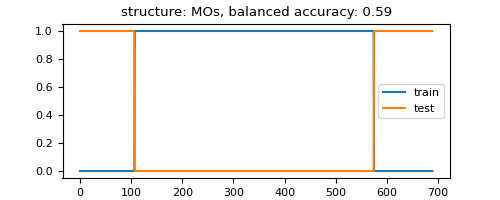

In [29]:
sel_row=84

sel_train_test_set=5
sel_test_set_indices=results['test_set_indices'].iloc[sel_row]==sel_train_test_set
sel_train_set_indices=results['train_set_indices'].iloc[sel_row]==sel_train_test_set

test_trial_numbers=results['test_trials'].iloc[sel_row][sel_test_set_indices]
train_trial_numbers=results['train_trials'].iloc[sel_row][sel_train_set_indices]

test_trial_vector=np.zeros(len(results['predict_proba'].iloc[sel_row]),dtype=bool)
train_trial_vector=np.zeros(len(results['predict_proba'].iloc[sel_row]),dtype=bool)

train_trial_vector[train_trial_numbers]=True
test_trial_vector[test_trial_numbers]=True

accuracy=results['balanced_accuracy_test_all'].iloc[sel_row][sel_train_test_set]
structure=results['structure'].iloc[sel_row]

fig,ax=plt.subplots(1,1,figsize=(5,2))
ax.plot(train_trial_vector,label='train')
ax.plot(test_trial_vector,label='test')
ax.legend()
ax.set_title(f'structure: {structure}, balanced accuracy: {accuracy:.2f}')

Text(0, 0.5, 'balanced accuracy')

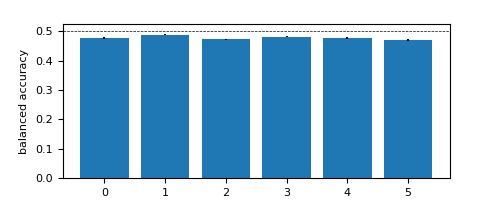

In [27]:
#get mean accuracy for each train-test set for a given structure
sel_structure='all'
if sel_structure=='all':
    structure_df=results.copy()
else:
    structure_df=results.query(f'structure=="{sel_structure}"')

balanced_accuracy_test_all=np.vstack(structure_df['balanced_accuracy_test_all'].values)
balanced_accuracy_test_mean=np.nanmean(balanced_accuracy_test_all,axis=0)
balanced_accuracy_test_sem=stats.sem(balanced_accuracy_test_all,axis=0,nan_policy='omit')

fig,ax=plt.subplots(1,1,figsize=(5,2))
ax.axhline(0.5,color='k',ls='--',lw=0.5)
# ax.errorbar(x=np.arange(len(balanced_accuracy_test_mean)),y=balanced_accuracy_test_mean,yerr=balanced_accuracy_test_sem)
ax.bar(x=np.arange(len(balanced_accuracy_test_mean)),height=balanced_accuracy_test_mean,yerr=balanced_accuracy_test_sem)
ax.set_xlabel('train-test set')
ax.set_ylabel('balanced accuracy')

In [30]:
session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.272.parquet"
session_table=pl.read_parquet(session_table_path)

session_list=(
    session_table.filter(
    # pl.col('project')=="DynamicRouting",
    pl.col('project')=="Templeton",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    # pl.col('is_good_behavior').eq(True),
    # pl.col('is_engaged').eq(True),
    )['session_id'].to_list()
    )

# block_dprime_threshold=1.0

# good_behavior_table={
#     'session_id':[],
#     'n_good_vis_blocks':[],
#     'n_good_aud_blocks':[],
# }

# for sel_session in session_list:
    
#     n_good_vis_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_vis_blocks'].to_numpy()[0]>=block_dprime_threshold)
#     n_good_aud_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_aud_blocks'].to_numpy()[0]>=block_dprime_threshold)

#     good_behavior_table['session_id'].append(sel_session)
#     good_behavior_table['n_good_vis_blocks'].append(n_good_vis_blocks)
#     good_behavior_table['n_good_aud_blocks'].append(n_good_aud_blocks)

# good_behavior_table=pd.DataFrame(good_behavior_table)
# session_list=good_behavior_table.query('n_good_vis_blocks>=2 and n_good_aud_blocks>=2')['session_id'].values

In [31]:
#select only relevant columns, then collect

results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/baseline_context_500ms_leave_2_blocks_out_crossval_10_units_strict_drift_1/" #all sessions, with crossval trials saved

results = pl.scan_parquet(
    results_path
).filter(
    pl.col('session_id').is_in(session_list)
).select(['structure','balanced_accuracy_test_all','test_set_indices','train_set_indices','test_trials','train_trials','session_id']).collect().to_pandas()

In [32]:
results

,structure,balanced_accuracy_test_all,test_set_indices,train_set_indices,test_trials,train_trials,session_id
0,VISpm,"[0.45117056856187293, 0.4654366094263792, 0.45...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[232, 233, 234, 235, 236, 237, 238, 239, 240, ...",644547_2022-12-06
1,VISpm,"[0.49156447417316984, 0.4505297771282426, 0.50...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[232, 233, 234, 235, 236, 237, 238, 239, 240, ...",644547_2022-12-06
2,VISpm,"[0.4901523597175771, 0.5157106320789185, 0.473...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[232, 233, 234, 235, 236, 237, 238, 239, 240, ...",644547_2022-12-06
3,VISpm,"[0.4574507617985879, 0.5270369017172086, 0.477...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[232, 233, 234, 235, 236, 237, 238, 239, 240, ...",644547_2022-12-06
4,VISpm,"[0.5305462653288741, 0.5252831567409573, 0.534...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[232, 233, 234, 235, 236, 237, 238, 239, 240, ...",644547_2022-12-06
...,...,...,...,...,...,...,...
7545,ACAd,"[0.48489906832298135, 0.5022488755622189, 0.52...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[227, 228, 229, 230, 231, 232, 233, 234, 235, ...",668759_2023-07-12
7546,ACAd,"[0.6065217391304347, 0.6105697151424287, 0.593...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[227, 228, 229, 230, 231, 232, 233, 234, 235, ...",668759_2023-07-12
7547,ACAd,"[0.5320263975155279, 0.49381559220389803, 0.56...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[227, 228, 229, 230, 231, 232, 233, 234, 235, ...",668759_2023-07-12
7548,ACAd,"[0.40477484472049685, 0.3950149925037481, 0.43...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[227, 228, 229, 230, 231, 232, 233, 234, 235, ...",668759_2023-07-12


Text(0, 0.5, 'balanced accuracy')

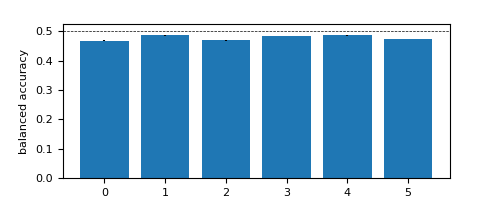

In [33]:
#get mean accuracy for each train-test set for a given structure
sel_structure='all'
if sel_structure=='all':
    structure_df=results.copy()
else:
    structure_df=results.query(f'structure=="{sel_structure}"')

balanced_accuracy_test_all=np.vstack(structure_df['balanced_accuracy_test_all'].values)
balanced_accuracy_test_mean=np.nanmean(balanced_accuracy_test_all,axis=0)
balanced_accuracy_test_sem=stats.sem(balanced_accuracy_test_all,axis=0,nan_policy='omit')

fig,ax=plt.subplots(1,1,figsize=(5,2))
ax.axhline(0.5,color='k',ls='--',lw=0.5)
# ax.errorbar(x=np.arange(len(balanced_accuracy_test_mean)),y=balanced_accuracy_test_mean,yerr=balanced_accuracy_test_sem)
ax.bar(x=np.arange(len(balanced_accuracy_test_mean)),height=balanced_accuracy_test_mean,yerr=balanced_accuracy_test_sem)
ax.set_xlabel('train-test set')
ax.set_ylabel('balanced accuracy')